In [1]:
import pandas as pd
data_mubawab = pd.read_csv("scrapping/data/data_mubawab_clean.csv")

In [83]:
data_mubawab.head()

,property_type,location,price_m2,arondissement
0,Villa,Oasis,19645.61,Aïn Chock
2,Appartement,Aïn Sebaâ,11404.52,Aïn Sebaâ
3,Appartement,Diab Extension,13725.49,Anfa
4,Appartement,Beauséjour,11538.46,Maârif
5,Appartement,Roches Noires,11025.64,Sidi Belyout


In [3]:
import numpy as np
data_mubawab['property_type'] = np.where(
    data_mubawab['property_type'].str.contains('Appartement|Studio|Duplex|Maison', case=False, na=False), 'Appartement',
    np.where(
        data_mubawab['property_type'].str.contains('Villa', case=False, na=False), 'Villa',
        'Autre'
    )
)
data_mubawab = data_mubawab[data_mubawab['property_type']!='Autre']
data_mubawab['property_type'].value_counts()


property_type
Appartement    1709
Villa           390
Name: count, dtype: int64

In [66]:

# Obtenir les locations uniques
locations_uniques = data_mubawab['location'].unique()
print(f"Nombre de locations uniques: {len(locations_uniques)}")
locations_uniques


Nombre de locations uniques: 48


<StringArray>
[            'Oasis',         'Aïn Sebaâ',    'Diab Extension',
        'Beauséjour',     'Roches Noires',          'Ain Diab',
    'Les princesses',            'Maarif',           'Palmier',
          'Gauthier',          'Laymoune',     'Hay Mohammadi',
      'Les Hôpitaux',         'Bourgogne',           'Riviera',
       'Sidi Moumen',      'Finance City',              'Anfa',
         'Belvédère',       'Mers Sultan',      'Sidi Maârouf',
  'Quartier Bachkou',        'Californie',   'Alsace Lorraine',
       'Derb Ghalef',        'Val Fleury',         'Aïn Chock',
       'Hay Hassani',          'Nassim 1',            'Medina',
          'Nassim 2',        'Hay Chrifa',             'Oulfa',
           'El Hank',        'La Gironde', 'Casablanca Marina',
           'Al Qods',       'Dar Bouazza',      'Centre Ville',
        'Hay Salama',            'Salmia',          'Palmiers',
           'El Fida',         'Hay Salam',      'Sidi Belyout',
      'Sidi Othmane',     

In [ ]:
def map_quartier(quartier):
    if not isinstance(quartier, str):
        return None

    mapping = {
        'Oasis': 'Aïn Chock',
        'Anfa': 'Anfa',
        'Aïn Sebaâ': 'Aïn Sebaâ',
        'Diab Extension': 'Anfa',
        'Beauséjour': 'Maârif',
        'Roches Noires': 'Sidi Belyout',
        'Ain Diab': 'Anfa',
        'Les Princesses': 'Maârif',
        'Maarif': 'Maârif',
        'Palmier': 'Maârif',
        'Gauthier': 'Anfa',
        'Laymoune': 'Aïn Chock',
        'Hay Mohammadi': 'Hay Mohammadi',
        'Californie': 'Aïn Chock',
        'Les Hôpitaux': 'Anfa',
        'Bourgogne': 'Anfa',
        'Riviera': 'Anfa',
        'Sidi Moumen': 'Sidi Moumen',
        'Finance City': 'Hay Hassani',
        'Belvédère': 'Sidi Belyout',
        'Mers Sultan': 'Mers Sultan',
        'Sidi Maârouf': 'Aïn Chock',
        'Quartier Bachkou': 'Aïn Chock',
        'Centre Ville': 'Sidi Belyout',
        'Alsace Lorraine': 'Anfa',
        'Derb Ghalef': 'Maârif',
        'Val Fleury': 'Maârif',
        'Aïn Chock': 'Aïn Chock',
        'Hay Hassani': 'Hay Hassani',
        'Riad': 'Aïn Chock',
        'Nassim 1': 'Sidi Moumen',
        'Medina': 'Sidi Belyout',
        'Nassim 2': 'Sidi Moumen',
        'Hay Chrifa': 'Hay Hassani',
        'Oulfa': 'Hay Hassani',
        'El Hank': 'Anfa',
        'La Gironde': 'Sidi Belyout',
        'Casablanca Marina': 'Sidi Belyout',
        'Al Qods': 'Al Fida',
        'Dar Bouazza': 'Dar Bouazza',
        'Hay Salama': 'Hay Mohammadi',
        'Salmia': 'Sidi Moumen',
        'Palmiers': 'Maârif',
        'El Fida': 'Al Fida',
        'Hay Salam': "Ben M'sik",
        'Sidi Belyout': 'Sidi Belyout',
        'Sidi Othmane': 'Sidi Othman',
        'Derb Sultan': 'Al Fida',
        'Bir Anzarane': 'Aïn Chock'
    }

    # 🔹 nettoyage
    quartier_clean = quartier.strip().title()

    return mapping.get(quartier_clean, "Unknown")

In [5]:
data_mubawab["arrondissement"] = data_mubawab["location"].apply(map_quartier)

In [6]:
Q1 = data_mubawab["price_m2"].quantile(0.25)
Q3 = data_mubawab["price_m2"].quantile(0.75)

IQR = Q3 - Q1

df_clean = data_mubawab [
    (data_mubawab["price_m2"] >= Q1 - 1.5 * IQR) &
    (data_mubawab["price_m2"] <= Q3 + 1.5 * IQR)
]
data_mubawab.groupby(['property_type','arrondissement'])['price_m2'].mean()

property_type  arrondissement
Appartement    Al Fida            11808.993810
               Anfa               27195.043601
               Aïn Chock          16409.922754
               Aïn Sebaâ          11879.748941
               Ben M'sik           6769.230000
               Dar Bouazza        16299.240000
               Hay Hassani        17416.240530
               Hay Mohammadi      30812.330000
               Maârif             17662.922848
               Mers Sultan        13649.277000
               Sidi Belyout       14327.607568
               Sidi Moumen         8348.334375
               Sidi Othman         8671.046667
Villa          Al Fida            21547.372500
               Anfa               34764.550175
               Aïn Chock          16811.102606
               Aïn Sebaâ          13572.613333
               Dar Bouazza        21176.470000
               Hay Hassani       305221.838571
               Maârif             21388.520000
               Mers Sultan    

In [ ]:
df = data_mubawab.groupby(['property_type','arrondissement'])['price_m2'].mean()
df.to_csv("data_mubawab_grouped_arrondissement.csv")

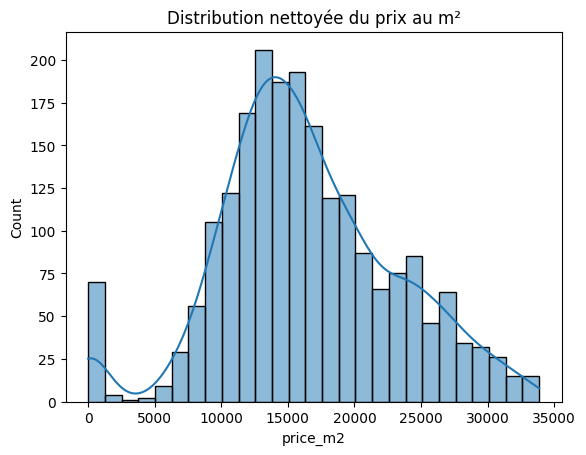

In [41]:
Q1 = data_mubawab["price_m2"].quantile(0.25)
Q3 = data_mubawab["price_m2"].quantile(0.75)

IQR = Q3 - Q1

df_clean = data_mubawab[
    (data_mubawab["price_m2"] >= Q1 - 1.5 * IQR) &
    (data_mubawab["price_m2"] <= Q3 + 1.5 * IQR)
]

sns.histplot(df_clean["price_m2"], kde=True)
plt.title("Distribution nettoyée du prix au m²")
plt.show()